# Project 1
## Centrality Measures in the 118th US Congress
#### Maxfield Raynolds
#### Data 620
#### Spring 2026

[YouTube video of Project1](https://youtu.be/OZlz_4-4VZ4)

#### Abstract

There can be little doubt that politics is inherently a network that operates off of influence. During the course of a congressional session, members of congress sponsor bills and then recruit co-sponsors as part of developing support for the bill. This process lends itself to creating a rich network of cosponsorships and opportunities to leverage influence.

Analyzing this network, created by bill cosponsorships creates an opportunity to analyze centrality. Which members of Congress have the greatest degree of closeness? of centrality? of betweenness centrality? And which ones are "gray cardinals", able to influence power without having an obviously central role?

This project explores these concepts by calculating degree centrality, closeness centrality, betweenness centrality and Eigenvector centrality of the 118th US Congress.

Initial expectations were that the party in the majority and Congressional leadership would have more central figures and greater degrees of centrality than others.

However, the result did not bear this out. While all measures of centrality generally had same figures atop the list, the division between party was almost even for the top 11 central figures, with Republicans having only one more central figure than the Democratic party.  This indicates that more central figures are likely acting bipartisanly, co-sponsoring bills on both sides of the aisle. This makes sense, a central figure will be engaged with both parties; if they were not they would not be central.

Additionally, there were no members of leadership of either party that were a top central figure. This, in hindsight, also makes sense. There is an extent to which it is more valuable for leadership to stay relatively neutral, the political fallout of committing to too many things could reduce the perception of their power. As a result, they are less likely to be a central figure.

#### Analysis

The following code loads necessary packages for the analysis.

In [1]:
from os import getcwd

# Import packages
import requests
import networkx as nx
import pandas as pd
import time
import os
import numpy as np
from itertools import combinations
from collections import Counter
from scipy.stats import ttest_ind

The data for this project was collected using the official Congressional API. Below are the variable set to make the API call.

In [2]:
 # set variables for api call for bill numbers

 # api key
 api = os.getenv('CONGRESS_API_KEY')

 # searching for congress number 118
 congress = 118

 # searching for bill type
 bill_type = 'hr'

 offset = 0

 limit = 250

 # url
 url = f'https://api.congress.gov/v3/bill/{congress}/{bill_type}?format=json&offset={offset}&limit={limit}&api_key={api}'

Below a function is defined to make an API call that collects all the bill numbers for the specified session of congress.

In [3]:
def api_number_call(api, congress, bill_type, offset = 0, limit = 250, bill_num_list = None):
    if bill_num_list is None:
        bill_num_list = []

    url = f'https://api.congress.gov/v3/bill/{congress}/{bill_type}?format=json&offset={offset}&limit={limit}&api_key={api}'

    r = requests.get(url)

    if r.status_code != 200:
        print('Error:', r.status_code)
        return bill_num_list

    data = r.json()
    bills = data.get('bills', [])

    df = pd.DataFrame(bills)
    numbers = df['number'].tolist()

    bill_num_list.extend(numbers)

    if len(numbers) < limit:
        return bill_num_list

    return api_number_call(api, congress, bill_type, offset=offset+limit, limit=limit, bill_num_list = bill_num_list)

This code makes the api call to collect the bill numbers, but is preceded by an "if not" statement to ensure that it is not run unnecessarily as it takes quite a long time.

In [4]:
# make api call
if not os.path.exists('cosponsors.parquet'):
    bill_num_list = api_number_call(api, congress, bill_type)

Then an api call function is defined to use the collected bill numbers to acquire all the co-sponsors of each bill number.

In [5]:
def cosponsor_call(api, congress, bill_type):

    frames = []

    for bill in bill_num_list:
        url = f'https://api.congress.gov/v3/bill/{congress}/{bill_type}/{bill}/cosponsors?format=json&api_key={api}'

        r = requests.get(url)

        if r.status_code != 200:
            print(f'Error on bill {bill}: {r.status_code}')
            continue

        data = r.json()
        cosponsors = data.get('cosponsors', [])

        if cosponsors:
            frame = pd.DataFrame(cosponsors)
            frame['bill_number'] = bill
            frames.append(frame)

        time.sleep(0.2)

    if frames:
        return pd.concat(frames, ignore_index=True)
    else:
        return pd.DataFrame()

Then the function is run to acquire the co-sponsors associated with each bill number but is inside a conditional statement that will limit whether it runs based on if there is already a saved version of the file.

In [6]:
if os.path.exists('cosponsors.parquet'):
    df_cosponsor = pd.read_parquet('cosponsors.parquet')
else:
    df_cosponsor = cosponsor_call(api, congress, bill_type)
    df.to_parquet('cosponsors.parquet', index=False)
    df_cosponsor.to_pickle("cosponsors.pkl")

The data is set into the useable cache from the saved file.

In [7]:
df_cosponsor = pd.read_parquet("cosponsors.parquet")

The data is then cleaned a little to ensure proper data types and consistent name formatting, as the original includes some name as all capitals and some with just the capitalization of the first letter.

In [8]:
df_cosponsor['sponsorshipDate'] = pd.to_datetime(df_cosponsor['sponsorshipDate'])
df_cosponsor['sponsorshipWithdrawnDate'] = pd.to_datetime(df_cosponsor['sponsorshipWithdrawnDate'])
df_cosponsor['bill_number'] = pd.to_numeric(df_cosponsor['bill_number'])
df_cosponsor = df_cosponsor[df_cosponsor['sponsorshipWithdrawnDate'].isna()]
df_cosponsor['firstName'] = df_cosponsor['firstName'].str.lower()
df_cosponsor['firstName'] = df_cosponsor['firstName'].str.title()
df_cosponsor['lastName'] = df_cosponsor['lastName'].str.lower()
df_cosponsor['lastName'] = df_cosponsor['lastName'].str.title()
df_cosponsor['fullName'] = df_cosponsor['firstName'] + ' ' + df_cosponsor['lastName']
df_cosponsor['fullName'] = df_cosponsor['fullName'].str.title()

Below is a look at whether there are null values inside the dataset and whether they should be filtered out.

In [9]:
df_cosponsor.isna().sum()

bioguideId                      0
district                        0
firstName                       0
fullName                        0
isOriginalCosponsor             0
lastName                        0
party                           0
sponsorshipDate                 0
state                           0
url                             0
middleName                  47050
sponsorshipWithdrawnDate    72123
bill_number                     0
dtype: int64

A quick check on the data types.

In [10]:
df_cosponsor.info()

<class 'pandas.DataFrame'>
Index: 72123 entries, 0 to 72670
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   bioguideId                72123 non-null  str           
 1   district                  72123 non-null  int64         
 2   firstName                 72123 non-null  str           
 3   fullName                  72123 non-null  str           
 4   isOriginalCosponsor       72123 non-null  bool          
 5   lastName                  72123 non-null  str           
 6   party                     72123 non-null  str           
 7   sponsorshipDate           72123 non-null  datetime64[us]
 8   state                     72123 non-null  str           
 9   url                       72123 non-null  str           
 10  middleName                25073 non-null  str           
 11  sponsorshipWithdrawnDate  0 non-null      datetime64[us]
 12  bill_number               72123 no

Then a peek at the dataframe.

In [11]:
df_cosponsor.head()

,bioguideId,district,firstName,fullName,isOriginalCosponsor,lastName,party,sponsorshipDate,state,url,middleName,sponsorshipWithdrawnDate,bill_number
0,R000610,14,Guy,Guy Reschenthaler,True,Reschenthaler,R,2023-01-09,PA,https://api.congress.gov/v3/member/R000610?for...,NaN,NaT,27
1,S001196,21,Elise,Elise Stefanik,True,Stefanik,R,2023-01-09,NY,https://api.congress.gov/v3/member/S001196?for...,M.,NaT,27
2,V000134,24,Beth,Beth Van Duyne,True,Van Duyne,R,2023-01-09,TX,https://api.congress.gov/v3/member/V000134?for...,NaN,NaT,27
3,N000189,4,Dan,Dan Newhouse,True,Newhouse,R,2023-01-09,WA,https://api.congress.gov/v3/member/N000189?for...,NaN,NaT,27
4,J000299,4,Mike,Mike Johnson,True,Johnson,R,2023-01-09,LA,https://api.congress.gov/v3/member/J000299?for...,NaN,NaT,27


The following code creates a list of pairs of everyone who co-sponsors each bill to be used to create the edges of the network.

In [12]:
pairs = (
    df_cosponsor.groupby('bill_number')['fullName']
        .apply(lambda x: list(combinations(sorted(x), 2)))
        .explode()
        .dropna()
        .reset_index(drop=True)
)

pairs = pd.DataFrame(pairs.tolist(), columns=['name_1', 'name_2'])

The paris are then converted to a weighted dataframe, the weight is based on number of bills that each pair co-sponsors.

In [13]:
edges = pd.DataFrame(pairs.groupby(['name_1','name_2']).value_counts().reset_index(drop=False))
edges['weight'] = edges['count']
edges.drop('count', axis=1, inplace=True)
edges = edges.drop_duplicates()
edges

,name_1,name_2,weight
0,A. Ferguson,Aaron Bean,3
1,A. Ferguson,Abigail Spanberger,1
2,A. Ferguson,Adam Schiff,1
3,A. Ferguson,Adam Smith,1
4,A. Ferguson,Adrian Smith,24
...,...,...,...
73378,Yadira Caraveo,Zoe Lofgren,17
73379,Young Kim,Zachary Nunn,20
73380,Young Kim,Zoe Lofgren,5
73381,Yvette Clarke,Zoe Lofgren,10


Then a dataframe is created to serves as the nodes and the node attributes. The nodes are each congress person who sponsored or cosponsored a bill and the attributes are their party, state they represent, and their district number.

In [14]:
df_nodes = pd.DataFrame()
df_nodes['node'] = df_cosponsor['fullName']
df_nodes['party'] = df_cosponsor['party']
df_nodes['state'] = df_cosponsor['state']
df_nodes['district'] = df_cosponsor['district']
df_nodes = df_nodes.drop_duplicates()
df_nodes.sort_values(by='node', inplace=True, ascending=True, ignore_index=True)

In [15]:
df_nodes

,node,party,state,district
0,A. Ferguson,R,GA,3
1,Aaron Bean,R,FL,4
2,Abigail Spanberger,D,VA,7
3,Adam Schiff,D,CA,28
4,Adam Smith,D,WA,9
...,...,...,...,...
453,Yadira Caraveo,D,CO,8
454,Young Kim,R,CA,40
455,Yvette Clarke,D,NY,9
456,Zachary Nunn,R,IA,3


Using the dataframe created for the edges, a network graph object is formed.

In [16]:
G = nx.from_pandas_edgelist(
    edges,
    source='name_1',
    target='name_2',
    edge_attr=['weight'],
    create_using=nx.Graph(),
)

Then atrribute are assigned to the nodes.

In [17]:
node_attribute_dict = df_nodes.set_index('node').to_dict('index')
nx.set_node_attributes(G, node_attribute_dict)

Then a few aspects of the network are calculated:

In [18]:
print(len(G.nodes),"nodes")
print(len(G.edges),"edges")
print("Network Diameter:",nx.diameter(G))
counts = Counter(data['party'] for _, data in G.nodes(data=True))
print("Node counts by party:", counts)

458 nodes
73383 edges
Network Diameter: 3
Node counts by party: Counter({'R': 232, 'D': 226})


Here is a peek at the network. It is quite a hairball.

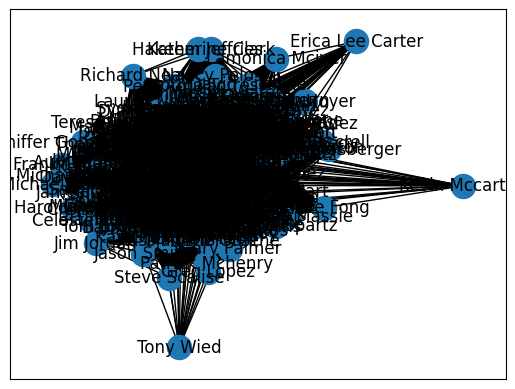

In [19]:
nx.draw_networkx(G)

 This markdown block saves the data for import into Gephi.

In [20]:
 nx.write_gml(G, 'project1.gml')

When imported into Gephi and colored by party, the graph appears as a very uniform hairball. This graph stresses the extent to which the members of congress are interconnected

<img src="project1graph.png" width="1600" height="800" />

## Centrality

#### Degree Centrality
The degree of centrality is calculated and a funciton is used to sort it.

In [21]:
d = nx.degree(G)

In [22]:
def sorted_map(G):
    G_dict = dict(G.degree())

    ms = sorted(G_dict.items(), key = lambda item: (-item[1],item[0]))
    return ms

Here is the first list of the top ten figures by degree centrality.

In [23]:
ds = sorted_map(G)

ds[:10]

[('Michael Lawler', 447),
 ('Don Bacon', 445),
 ('Brian Fitzpatrick', 444),
 ('Donald Davis', 438),
 ('Josh Gottheimer', 436),
 ('Nancy Mace', 433),
 ('Jimmy Panetta', 432),
 ('David Trone', 428),
 ('Eleanor Norton', 427),
 ('Maria Salazar', 427)]

#### Closeness Centrality

Closeness centrality is then calculated.

In [24]:
c = nx.closeness_centrality(G)

In [25]:
def sorted_map2(d):
    return sorted(d.items(), key = lambda item: (-item[1],item[0]))

In [26]:
cs = sorted_map2(c)

The resulting sorted list of closeness centrality is exactly the same as the degree centrality list. This is clearly a very central group of congress people.

In [27]:
cs[:10]

[('Michael Lawler', 0.9785867237687366),
 ('Don Bacon', 0.9744136460554371),
 ('Brian Fitzpatrick', 0.9723404255319149),
 ('Donald Davis', 0.9600840336134454),
 ('Josh Gottheimer', 0.9560669456066946),
 ('Nancy Mace', 0.9501039501039501),
 ('Jimmy Panetta', 0.9481327800829875),
 ('David Trone', 0.9403292181069959),
 ('Eleanor Norton', 0.9383983572895277),
 ('Maria Salazar', 0.9383983572895277)]

#### Betweenness Centrality

Betweenness centrality calculations yield a very similar list to the previous two lists. All but two names are the same, and the order is nearly identical.

In [28]:
b = nx.betweenness_centrality(G)
bs = sorted_map2(b)
bs[:10]

[('Michael Lawler', 0.001733216980761312),
 ('Don Bacon', 0.001649668409394085),
 ('Brian Fitzpatrick', 0.0016021884104491617),
 ('Eleanor Norton', 0.0015812012580073479),
 ('Donald Davis', 0.0015160401653871206),
 ('Josh Gottheimer', 0.0014830365551966789),
 ('Nancy Mace', 0.0014785941501128308),
 ('David Valadao', 0.0014776283001681427),
 ('David Trone', 0.0014538890884671935),
 ("Anthony D'Esposito", 0.0014451226393828445)]

#### Eigenvector centrality

Finally Eigenvector centrality is calculated, yielding a list that is also very similar to the previous three lists.

In [29]:
e = nx.eigenvector_centrality(G)
es = sorted_map2(e)
es[:10]

[('Michael Lawler', 0.06170842971503429),
 ('Don Bacon', 0.06159669136653237),
 ('Brian Fitzpatrick', 0.061558286475469286),
 ('Donald Davis', 0.06093084029568731),
 ('Josh Gottheimer', 0.06078096806098524),
 ('Jimmy Panetta', 0.06037775176185855),
 ('Nancy Mace', 0.06036356876506968),
 ('Maria Salazar', 0.05976111747029885),
 ('David Trone', 0.059716944987025074),
 ('Eleanor Norton', 0.05941408256360744)]

# Comparison

#### Considering All the Centrality Measures

The remaining code combines the top 10 members of the each centrality measure into a single dataframe.

In [30]:
df = pd.DataFrame({
    'name': list(G.nodes()),
    'degree': [d[n] for n in G.nodes()],
    'degree_centrality': [c[n] for n in G.nodes()],
    'betweenness': [b[n] for n in G.nodes()],
    'eigenvector': [e[n] for n in G.nodes()]
})

In [31]:
df.sort_values(by = 'degree_centrality', inplace=True, ascending=False)
df.head(10)

,name,degree,degree_centrality,betweenness,eigenvector
240,Michael Lawler,447,0.978587,0.001733,0.061708
101,Don Bacon,445,0.974414,0.001650,0.061597
45,Brian Fitzpatrick,444,0.972340,0.001602,0.061558
103,Donald Davis,438,0.960084,0.001516,0.060931
190,Josh Gottheimer,436,0.956067,0.001483,0.060781
263,Nancy Mace,433,0.950104,0.001479,0.060364
173,Jimmy Panetta,432,0.948133,0.001396,0.060378
88,David Trone,428,0.940329,0.001454,0.059717
222,Maria Salazar,427,0.938398,0.001356,0.059761
113,Eleanor Norton,427,0.938398,0.001581,0.059414


In [32]:
comparison = pd.merge(df, df_nodes, left_on='name', right_on='node')

In [33]:
comparison.head(10)

,name,degree,degree_centrality,betweenness,eigenvector,node,party,state,district
0,Michael Lawler,447,0.978587,0.001733,0.061708,Michael Lawler,R,NY,17
1,Don Bacon,445,0.974414,0.001650,0.061597,Don Bacon,R,NE,2
2,Brian Fitzpatrick,444,0.972340,0.001602,0.061558,Brian Fitzpatrick,R,PA,1
3,Donald Davis,438,0.960084,0.001516,0.060931,Donald Davis,D,NC,1
4,Josh Gottheimer,436,0.956067,0.001483,0.060781,Josh Gottheimer,D,NJ,5
5,Nancy Mace,433,0.950104,0.001479,0.060364,Nancy Mace,R,SC,1
6,Jimmy Panetta,432,0.948133,0.001396,0.060378,Jimmy Panetta,D,CA,19
7,David Trone,428,0.940329,0.001454,0.059717,David Trone,D,MD,6
8,Maria Salazar,427,0.938398,0.001356,0.059761,Maria Salazar,R,FL,27
9,Eleanor Norton,427,0.938398,0.001581,0.059414,Eleanor Norton,D,DC,0


The top names on the dataframe show a familiar set of names and a near even split between party. Ultimately, this analysis makes clear that being a central figure in the US Congress when considered from bill co-sponsorships leads to a group of people who are central across all measures. Whether, having them as co-sponsors increases the chances of the bill passing is not considered in this analysis, but it is does appear that these are people who are either easy to recruit to your bill or are important to recruit to your bill as their sponsorship may lead to or relate to more co-sponsorships.

## T-Tests

To further explore whether there a differences in the parties based on centrality, the code below prepares and runs a t-test of all the centrality measures.

In [34]:
r = comparison[comparison['party'] == 'R']
d = comparison[comparison['party'] == 'D']

In [35]:
cent = ['degree', 'degree_centrality', 'betweenness', 'eigenvector']

def comp_mode(df1, df2, list):
    rows = []

    for i in list:
        t_stat, p_value = ttest_ind(df1[i], df2[i], equal_var=False)
        rows.append({
            'metric':i,
            't_stat':t_stat,
            'p_value':p_value
        })
    return pd.DataFrame(rows)

In [36]:
t_tests = comp_mode(r, d, cent)
t_tests

,metric,t_stat,p_value
0,degree,-1.596556,0.111059
1,degree_centrality,-1.558848,0.119727
2,betweenness,-0.352507,0.724621
3,eigenvector,-2.024596,0.043493


When examining the results of the t-tests, almost all results show no statistically significant difference between the two parties. Only Eigenvector centrality comparison has a p-value below a 0.05 threshold indicating statistical significance. However, considering that three tests do not show statistical significance and that Eigenvector is only just below the threshold of significance, there is only a modest indicator of a statistical difference between the groups. Certainly, considering four tests were run, were a correction to be applied to the results, the Eigenvector p-value would not survive as significant.

What is perhaps more interesting is the negative t-stat for Eigenvector. Because of how the test was set up, this indicates that on average the Republicans have a lower Eigenvector centrality, indicating that Democrats are more connected to highly central nodes.  This observation is interesting considering the Republicans held the majority throughout the 118th Congress. This may be an indicator that because the party in power has de facto control of committees and overall institutional power, it is valuable for minority party members to strategically connect themselves to central nodes to maintain influence. This is potentially an interesting avenue for additional research.